# Simulation Playground Notebook
This notebook is designed as a easy einterface to call the functions that we have defined

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import torch.optim as optim
import torch.nn as nn
import torch

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from data_loader import load_participants_info, load_event_descriptions, load_behavioral_data, preprocess_data

# Data Preparation
Let's prepare some data first to fit our model. We are specifically using ["Locus coeruleus activity strengthens prioritized memories under arousal"](https://openneuro.org/datasets/ds002011/versions/1.0.0) dataset fror now.

In [2]:
DATASET_PATH = "data"
participants_df = load_participants_info(DATASET_PATH)
load_event_descriptions(DATASET_PATH)

df_behavior = load_behavioral_data(DATASET_PATH, "01")
for idx in range(2,11):
    sample_participant = f"0{idx}"
    df = load_behavioral_data(DATASET_PATH, sample_participant)
    df_behavior = pd.concat([df, df_behavior], ignore_index=True)

Let's preprocess our data first

In [3]:
X, Y, X_tensor, Y_tensor, scaler_X, scaler_Y, df_clean = preprocess_data(df_behavior)

X Shape: torch.Size([1699, 7]), Y Shape: torch.Size([1699])
Y Min: -1.0, Y Max: 1.0


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X_tensor, Y_tensor, test_size=0.2, random_state=42)

# Training

In [5]:
from train import (train_feed_forward_nn,
                   train_vanilla_rnn,
                   train_vanilla_lstm,
                   train_vanilla_lc_model,
                   train_lstm_lc_model,
                   train_ff_controller,
                   train_ff_uncertain_controller
                   )
from analysis.evaluation import evaluate_model

## Fully Connected Neural Network

To illustrate our idea, we want to train 2 models from math and computer science, which is our vanilla feed forward networks and an recurrent networks.

Epoch 0, Loss: 0.067869171500206
Epoch 100, Loss: 0.04590931907296181
Epoch 200, Loss: 0.04344598203897476
Epoch 300, Loss: 0.04307504743337631
Epoch 400, Loss: 0.04136115312576294
Epoch 500, Loss: 0.04044463858008385
Epoch 600, Loss: 0.03975636512041092
Epoch 700, Loss: 0.039724674075841904
Epoch 800, Loss: 0.03877406194806099
Epoch 900, Loss: 0.03843368589878082
Epoch 1000, Loss: 0.03895293176174164
Epoch 1100, Loss: 0.03860393539071083
Epoch 1200, Loss: 0.03827524930238724
Epoch 1300, Loss: 0.037500910460948944
Epoch 1400, Loss: 0.03704066574573517
Epoch 1500, Loss: 0.03785138949751854
Epoch 1600, Loss: 0.03781016543507576
Epoch 1700, Loss: 0.03636416047811508
Epoch 1800, Loss: 0.036724504083395004
Epoch 1900, Loss: 0.03629927709698677
Training complete!
Evaluating Model: FeedForwardNN


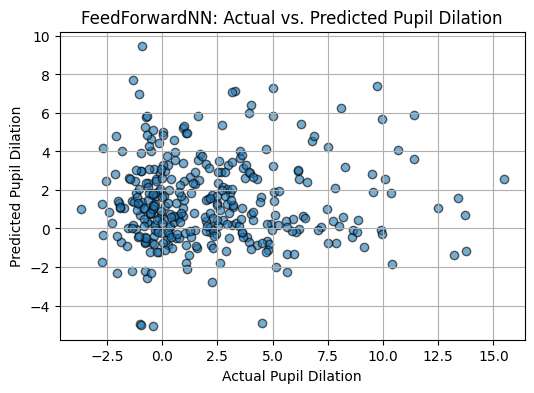

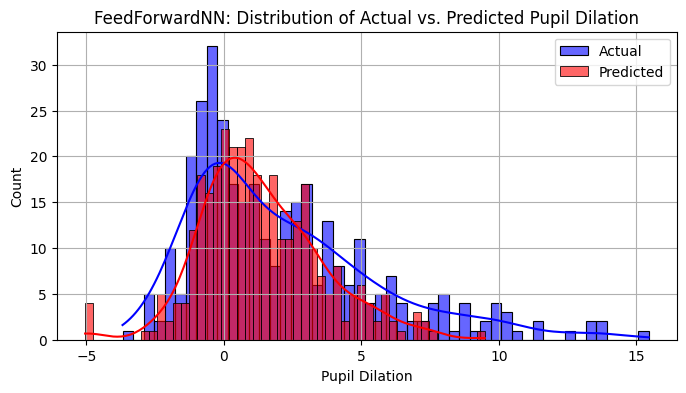

FeedForwardNN - Pearson Correlation: 0.0321


In [6]:
model_ff = train_feed_forward_nn(X_train, Y_train,epochs=2000)
evaluate_model(model_ff, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Recurent Neural Networks

We will  do the same thing with an recurrent neural network

In [7]:
# model_rnn = train_vanilla_rnn(X_train, Y_train, epochs=2000)
# evaluate_model(model_rnn, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM Models

In [8]:
# model_lstm = train_vanilla_lstm(X_train, Y_train, epochs=5000, hidden_dim=12)
# evaluate_model(model_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LCNECortex Fitter Model

Now coming to our customized LCNECortex model

Epoch 0, Loss: 0.4822876453399658


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.0875542163848877
Epoch 200, Loss: 0.09467141330242157
Epoch 300, Loss: 0.07305766642093658
Epoch 400, Loss: 0.05698288977146149
Epoch 500, Loss: 0.05614139139652252
Epoch 600, Loss: 0.08213356882333755
Epoch 700, Loss: 0.04142459109425545
Epoch 800, Loss: 0.046380266547203064
Epoch 900, Loss: 0.04387863725423813
Epoch 1000, Loss: 0.06462697684764862
Epoch 1100, Loss: 0.058011699467897415
Epoch 1200, Loss: 0.04652240872383118
Epoch 1300, Loss: 0.076348677277565
Epoch 1400, Loss: 0.07267261296510696
Epoch 1500, Loss: 0.0893547534942627
Epoch 1600, Loss: 0.082942433655262
Epoch 1700, Loss: 0.043378472328186035
Epoch 1800, Loss: 0.05858742073178291
Epoch 1900, Loss: 0.06737662851810455
Training complete!
Evaluating Model: LCNECortexFitter


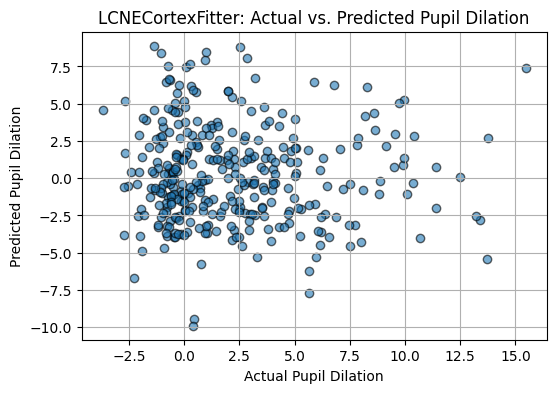

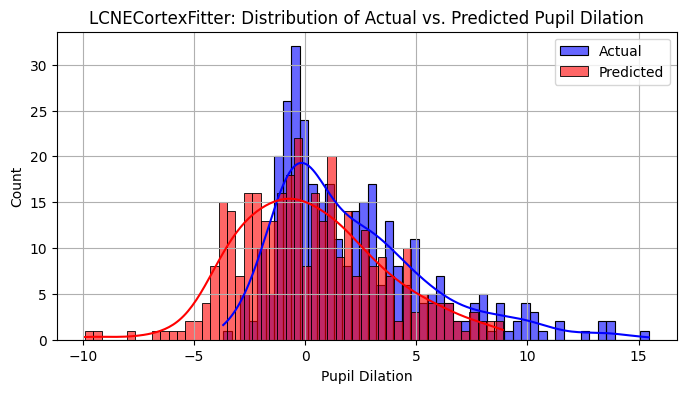

LCNECortexFitter - Pearson Correlation: -0.0274


In [9]:
model_lc_vanilla = train_vanilla_lc_model(X_train, Y_train, epochs=2000)
evaluate_model(model_lc_vanilla, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## LSTM LCNECortex Model

In [10]:
# model_lc_lstm = train_lstm_lc_model(X_train, Y_train, epochs=2000, hidden_dim=64)
# evaluate_model(model_lc_lstm, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

# FF Gadget Model

Epoch 0, Loss: 0.086065


/Users/kevinb/miniforge3/envs/cse251b/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 100, Loss: 0.030820
Epoch 200, Loss: 0.034501
Epoch 300, Loss: 0.023822
Epoch 400, Loss: 0.013280
Epoch 500, Loss: 0.029114
Epoch 600, Loss: 0.030205
Epoch 700, Loss: 0.029236
Epoch 800, Loss: 0.027453
Epoch 900, Loss: 0.033148
Epoch 1000, Loss: 0.026150
Epoch 1100, Loss: 0.024516
Epoch 1200, Loss: 0.032664
Epoch 1300, Loss: 0.021503
Epoch 1400, Loss: 0.033267
Epoch 1500, Loss: 0.025843
Epoch 1600, Loss: 0.023577
Epoch 1700, Loss: 0.017791
Epoch 1800, Loss: 0.027763
Epoch 1900, Loss: 0.027371
Epoch 2000, Loss: 0.037054
Epoch 2100, Loss: 0.014283
Epoch 2200, Loss: 0.028964
Epoch 2300, Loss: 0.018648
Epoch 2400, Loss: 0.011629
Epoch 2500, Loss: 0.015997
Epoch 2600, Loss: 0.030228
Epoch 2700, Loss: 0.030653
Epoch 2800, Loss: 0.048035
Epoch 2900, Loss: 0.024014
Epoch 3000, Loss: 0.021321
Epoch 3100, Loss: 0.021241
Epoch 3200, Loss: 0.016170
Epoch 3300, Loss: 0.034497
Epoch 3400, Loss: 0.038945
Epoch 3500, Loss: 0.018541
Epoch 3600, Loss: 0.028627
Epoch 3700, Loss: 0.023724
Epoch 3800

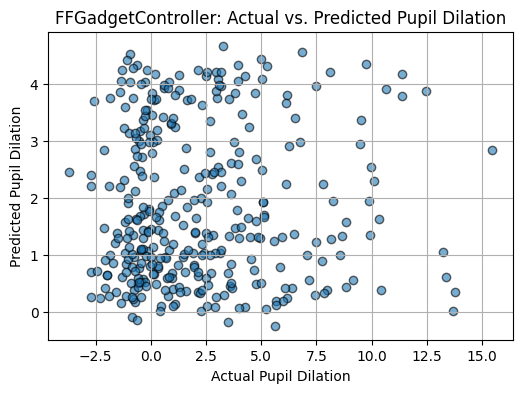

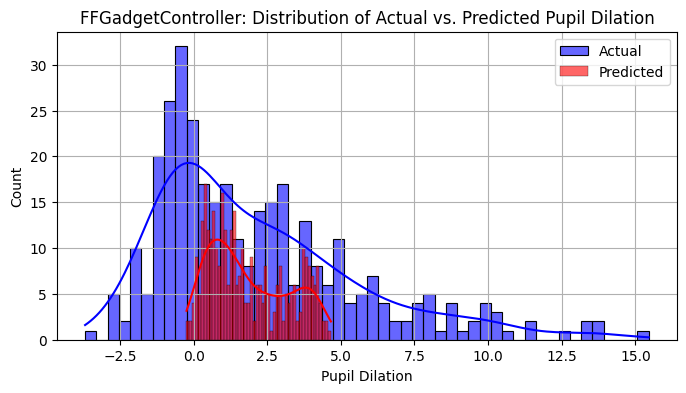

FFGadgetController - Pearson Correlation: 0.0330


In [11]:
ff_gadget = train_ff_controller(X_train, Y_train, epochs=5000, hidden_dim=264)
evaluate_model(ff_gadget, X_test, Y_test, df_clean, scaler_Y=scaler_Y)

## Modified Uncertainty GadgetModel

In [18]:
ff_uncertain_gadget = train_ff_uncertain_controller(X_tensor, Y_tensor, epochs=5000, hidden_dim=200)

Epoch 0, Loss: 0.159868
Epoch 100, Loss: 0.056139
Epoch 200, Loss: 0.024699
Epoch 300, Loss: 0.031250
Epoch 400, Loss: 0.017392
Epoch 500, Loss: 0.035190
Epoch 600, Loss: 0.041117
Epoch 700, Loss: 0.031207
Epoch 800, Loss: 0.032302
Epoch 900, Loss: 0.037656
Epoch 1000, Loss: 0.022770
Epoch 1100, Loss: 0.022576
Epoch 1200, Loss: 0.036764
Epoch 1300, Loss: 0.036586
Epoch 1400, Loss: 0.018293
Epoch 1500, Loss: 0.018472
Epoch 1600, Loss: 0.013249
Epoch 1700, Loss: 0.020337
Epoch 1800, Loss: 0.015809
Epoch 1900, Loss: 0.016927
Epoch 2000, Loss: 0.031735
Epoch 2100, Loss: 0.032897
Epoch 2200, Loss: 0.052627
Epoch 2300, Loss: 0.013236
Epoch 2400, Loss: 0.046542
Epoch 2500, Loss: 0.039189
Epoch 2600, Loss: 0.028193
Epoch 2700, Loss: 0.026196
Epoch 2800, Loss: 0.018687
Epoch 2900, Loss: 0.019706
Epoch 3000, Loss: 0.030151
Epoch 3100, Loss: 0.029861
Early stopping triggered at epoch 3129
Training complete!


# Analysis

In [24]:
from analysis.analysis import (pca_lcne_lstm,
                               pca_feed_forward,
                               pca_lcne,
                               pca_lstm,
                               analyze_ff_gadget_activations,
                               evaluate_ff_uncertainty_gadget
)

## Feed-Forward Neural Networks

In [15]:
# pca_feed_forward(model_ff, X_tensor, df_behavior)

## LCNECortex Model

We will see that, though  under fitted with the real data, there are some structureness to the data that we can play around with since we injected mechanistic insights into it.

Text(0.5, 1.0, 'Cortex Activation Distribution')

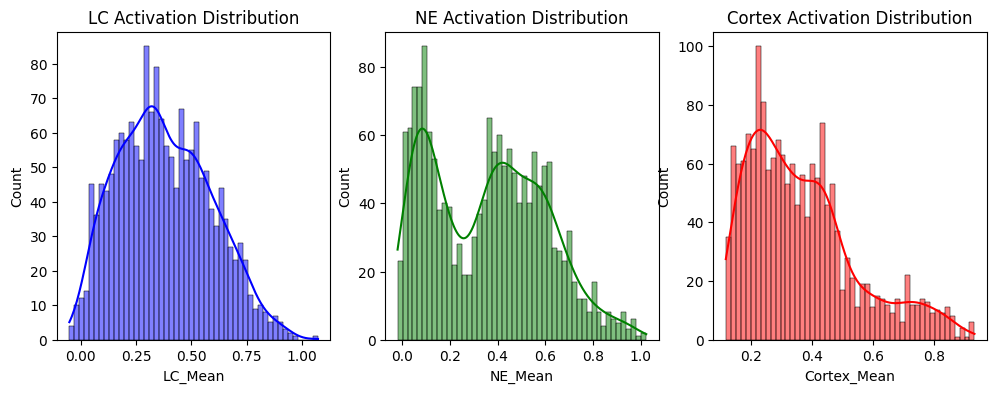

In [16]:
with torch.no_grad():
    prev_LC = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)
    prev_Cortex = torch.zeros(X_tensor.shape[0], model_lc_vanilla.hidden_dim)

    LC_act, NE_act, C_act, Pupil_pred, LC_raw, NE_raw, C_raw = model_lc_vanilla(X_tensor, prev_LC, prev_Cortex, return_activations=True)

act_lc = LC_act.cpu().numpy()
act_ne = NE_act.cpu().numpy()
act_cortex = C_act.cpu().numpy()

df_activations = pd.DataFrame({
    'LC_Mean': act_lc.mean(axis=1),
    'NE_Mean': act_ne.mean(axis=1),
    'Cortex_Mean': act_cortex.mean(axis=1),
    'PupilPred': Pupil_pred.cpu().numpy().squeeze(),
    'ActualPupil': df_clean['Event_PupilDilation'].values  # Ensure this aligns with X_tensor
})

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.histplot(df_activations['LC_Mean'], kde=True, bins=50, color='blue')
plt.title("LC Activation Distribution")

plt.subplot(1, 3, 2)
sns.histplot(df_activations['NE_Mean'], kde=True, bins=50, color='green')
plt.title("NE Activation Distribution")

plt.subplot(1, 3, 3)
sns.histplot(df_activations['Cortex_Mean'], kde=True, bins=50, color='red')
plt.title("Cortex Activation Distribution")

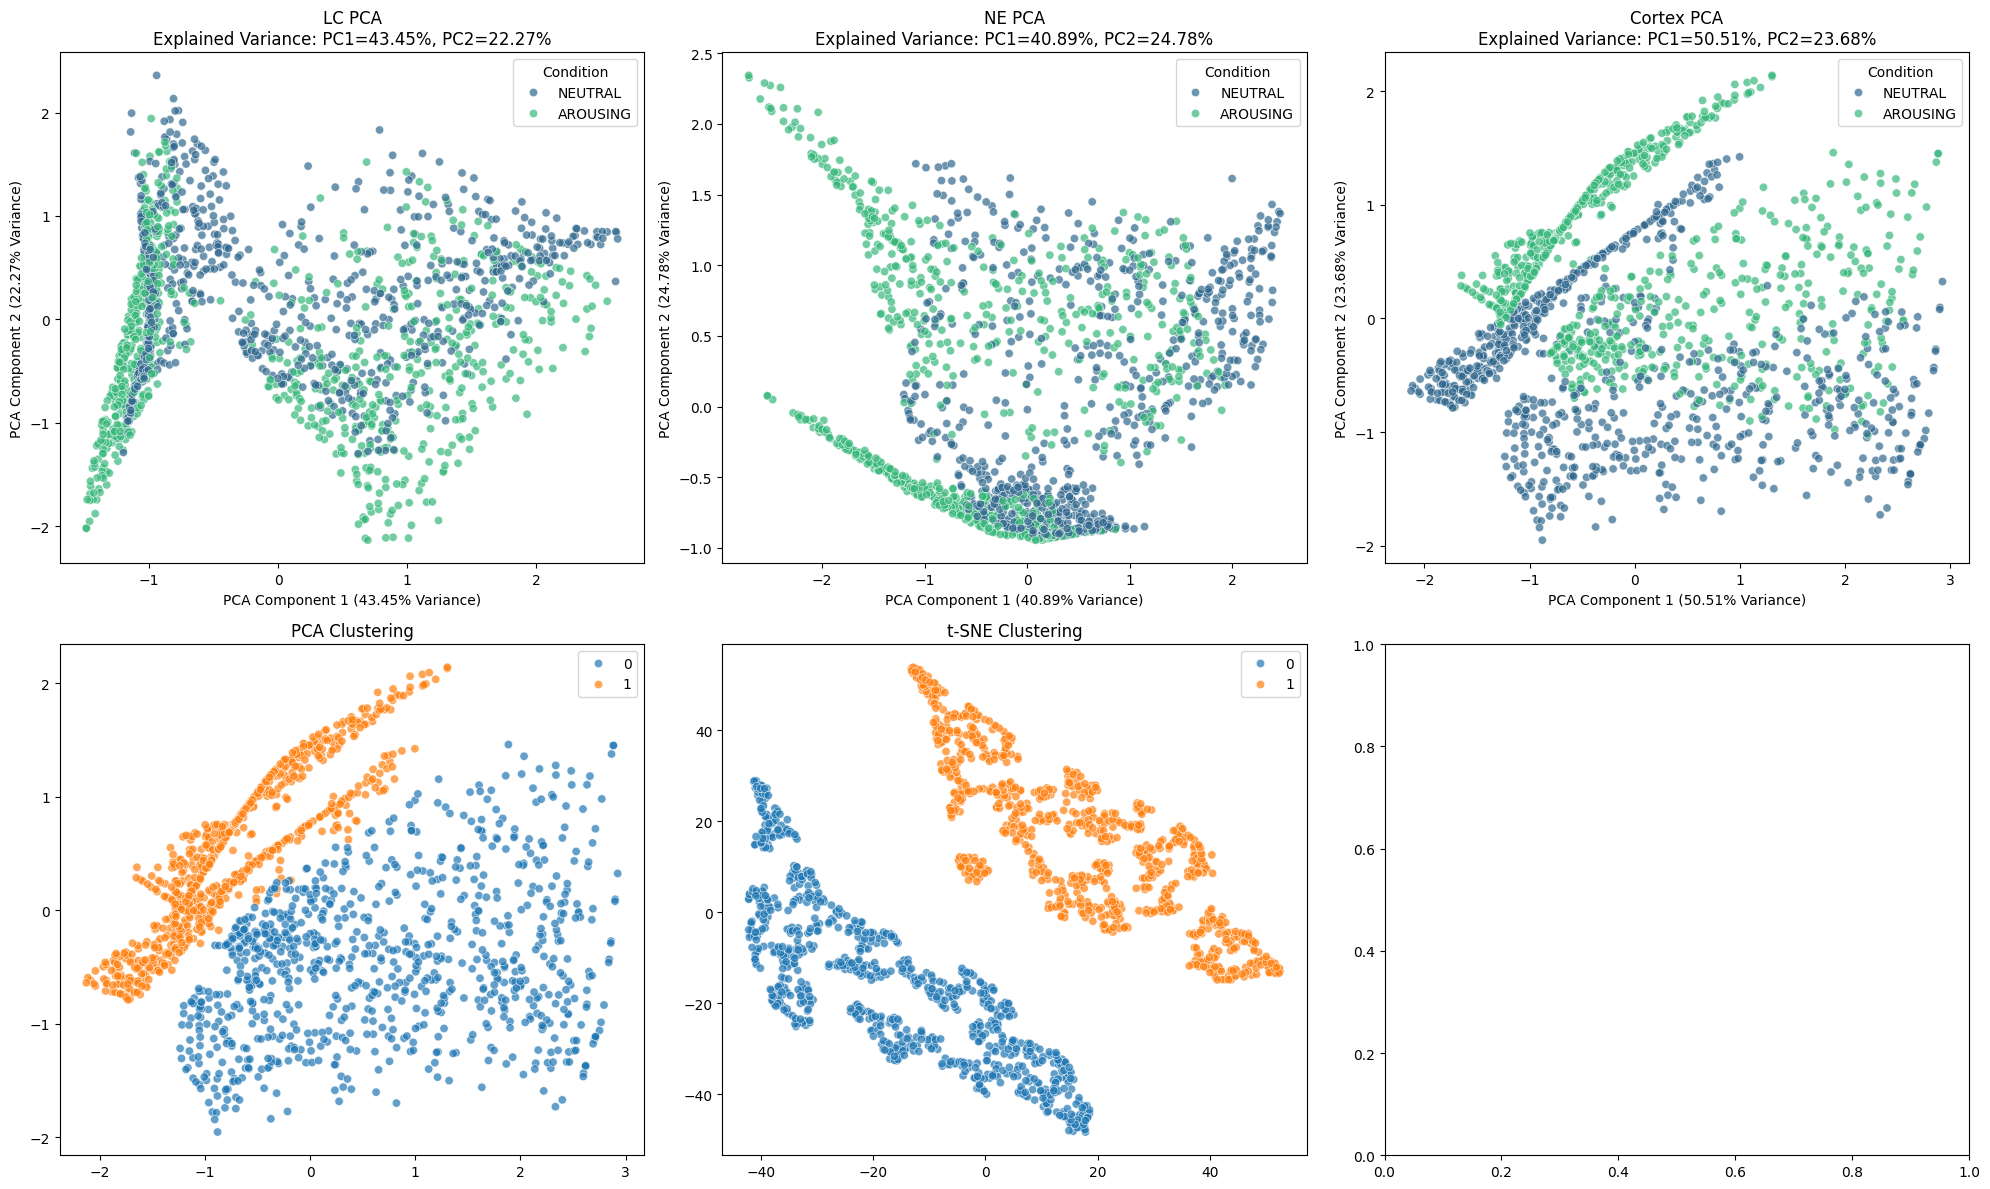

In [17]:
pca_lcne(model_lc_vanilla, X_tensor, df_clean)

## LSTM LCNECortex Model

In [18]:
# pca_lcne_lstm(model_lc_lstm, X_tensor, df_clean)

## Vanilla LSTM Comparison

In [19]:
# pca_lstm(model_lstm, X_test, df_clean)

## FF Gadget Model

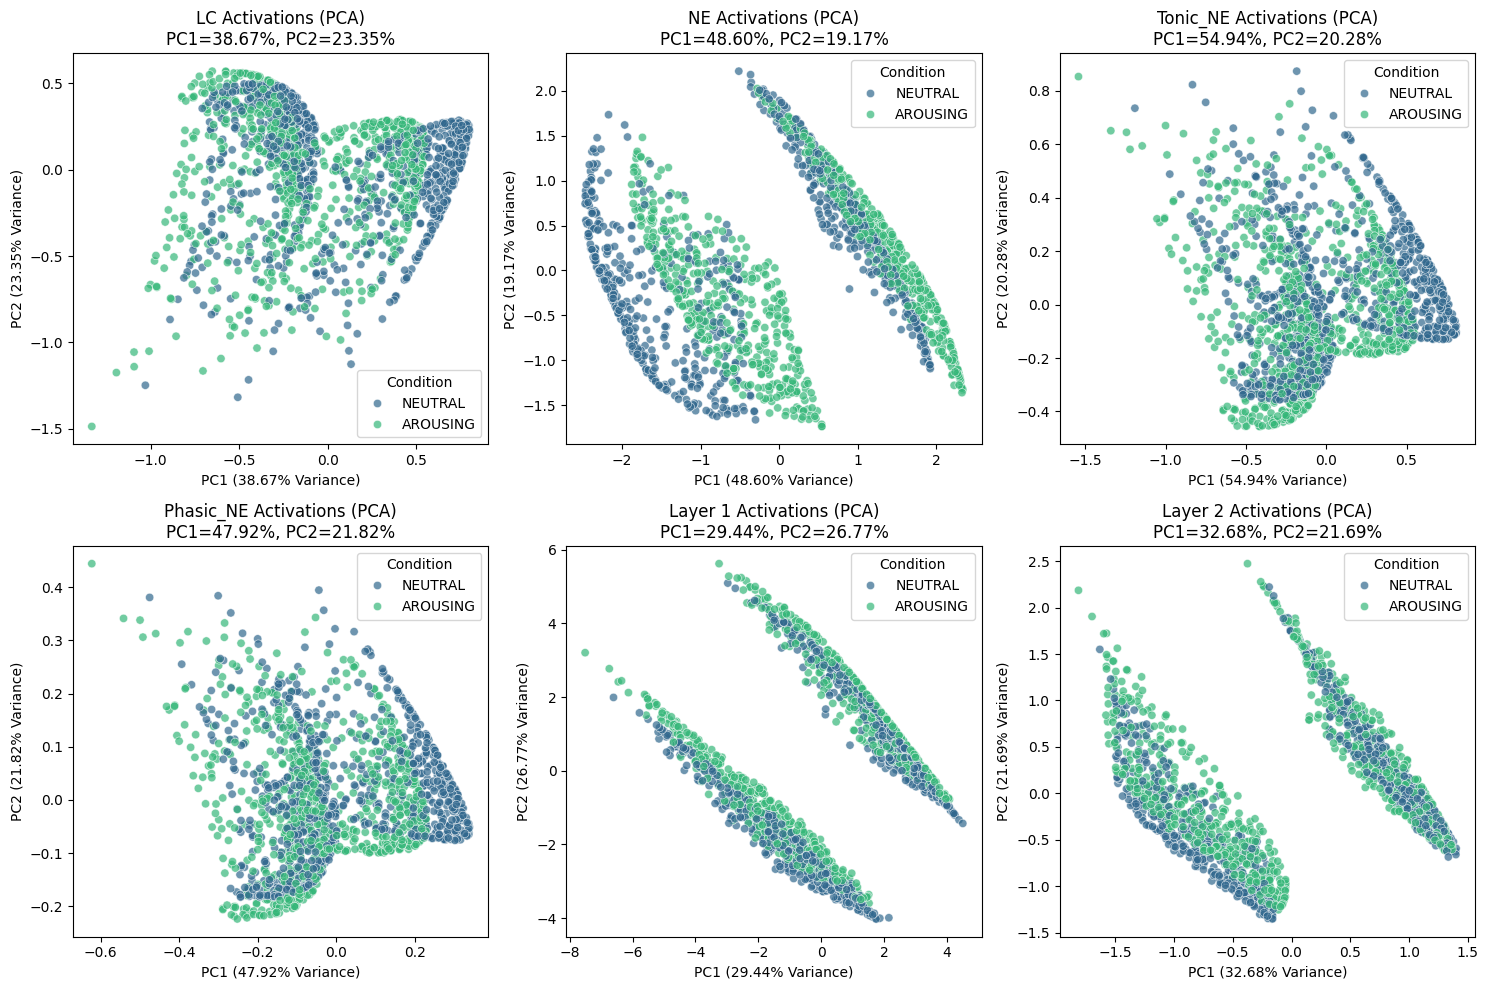

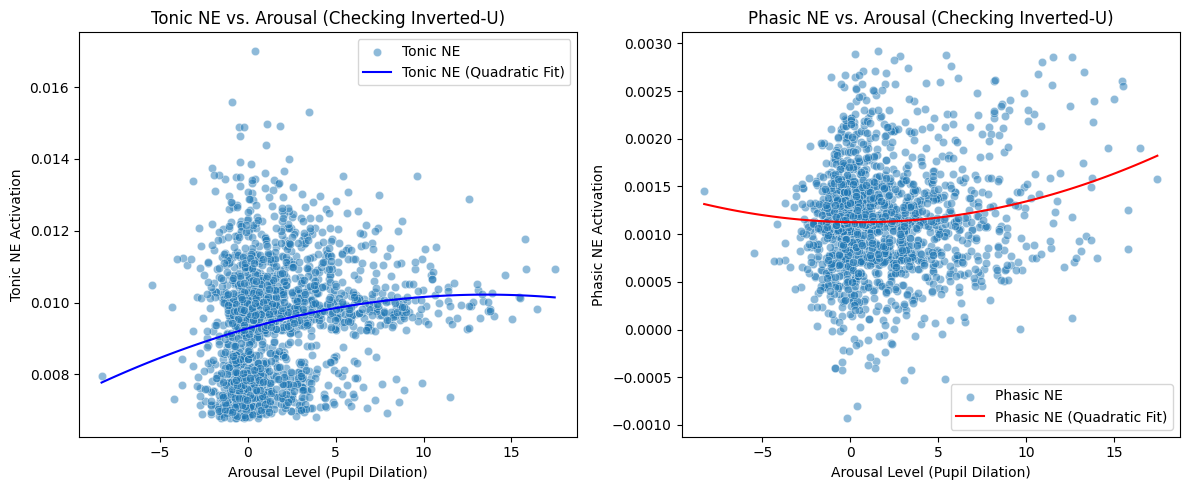


 Pearson Correlation with Actual Pupil Dilation:
LC: 0.242
NE: -0.299
Tonic_NE: 0.192
Phasic_NE: 0.106
Layer 1: 0.115
Layer 2: 0.071
Predicted Pupil Dilation: 0.443


In [20]:
analyze_ff_gadget_activations(ff_gadget, X_tensor, df_clean)

This model elarning representation is quite unstable

## Modified Uncertainty GadgetModel

Pupil Dilation MAE: 2.1795
Pupil Dilation MSE: 8.4891


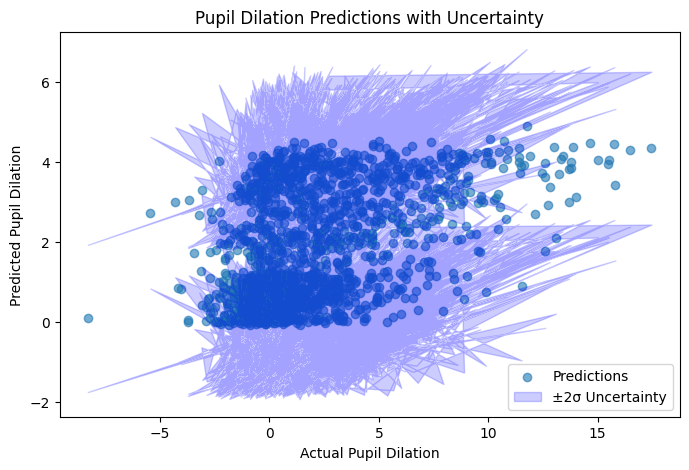

In [25]:
evaluate_ff_uncertainty_gadget(ff_uncertain_gadget, X_tensor, Y_tensor, scaler_Y)

In [38]:
from analysis.analysis import (extract_activations,
                               compute_mapper_graph,
                               compute_persistent_homology)

Analyzing LC activations...


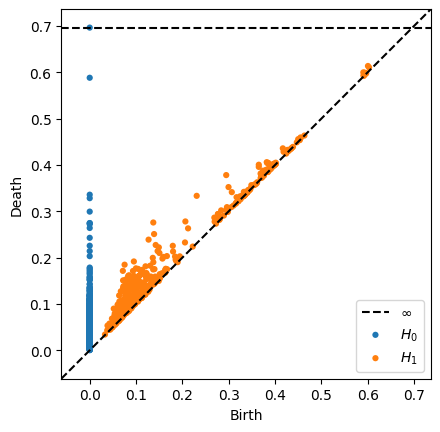

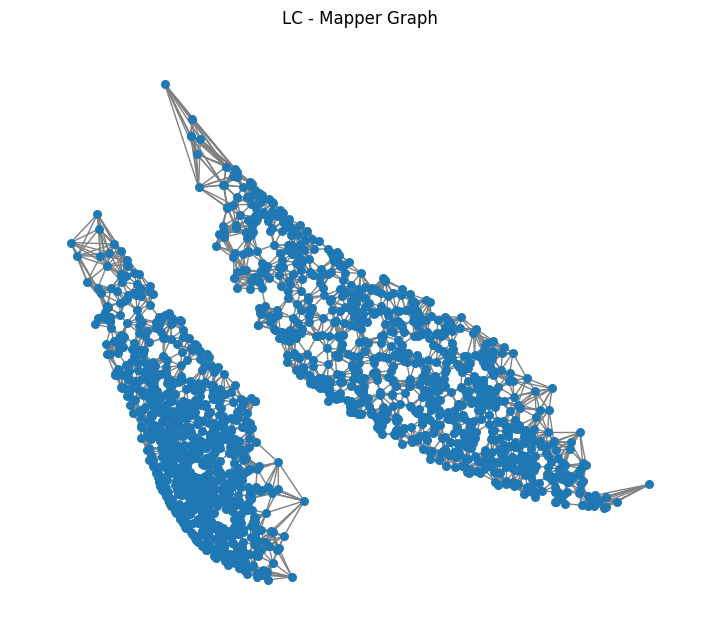

Analyzing NE activations...


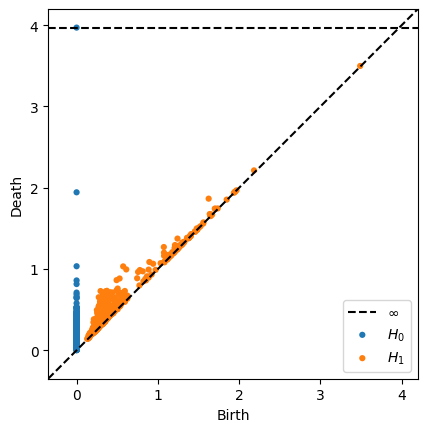

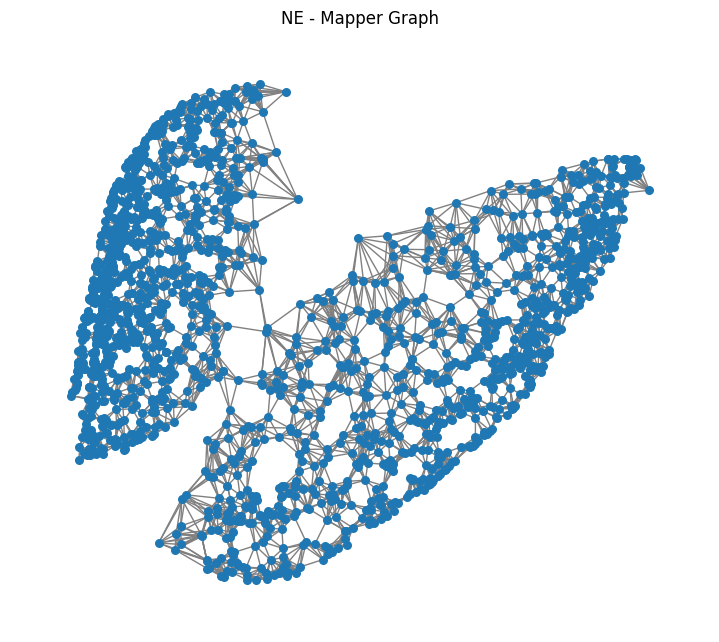

Analyzing Tonic_NE activations...


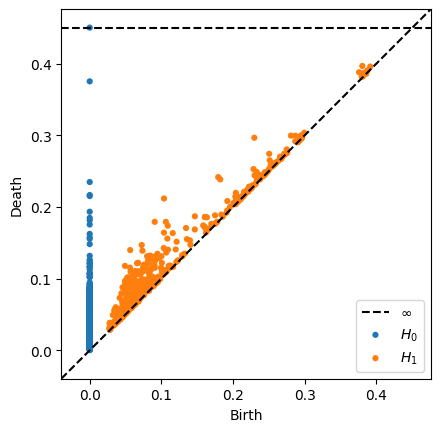

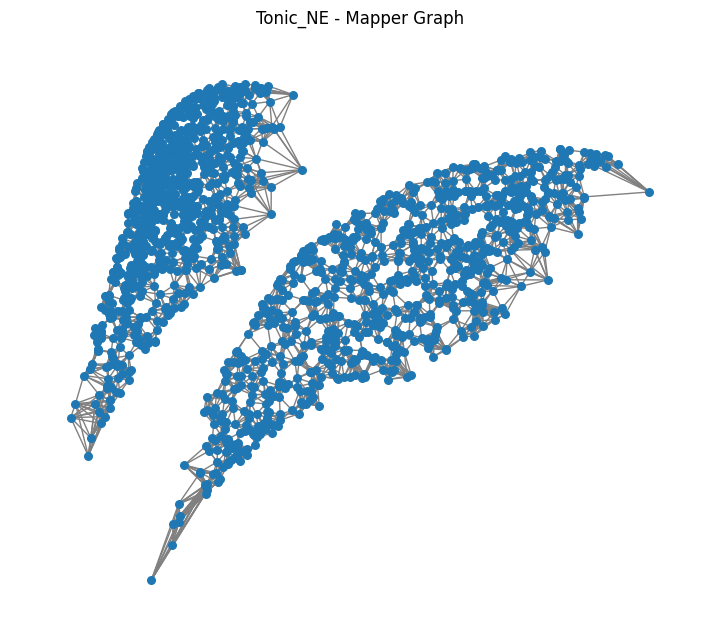

Analyzing Phasic_NE activations...


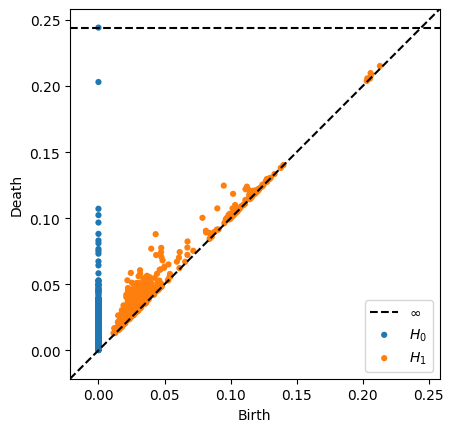

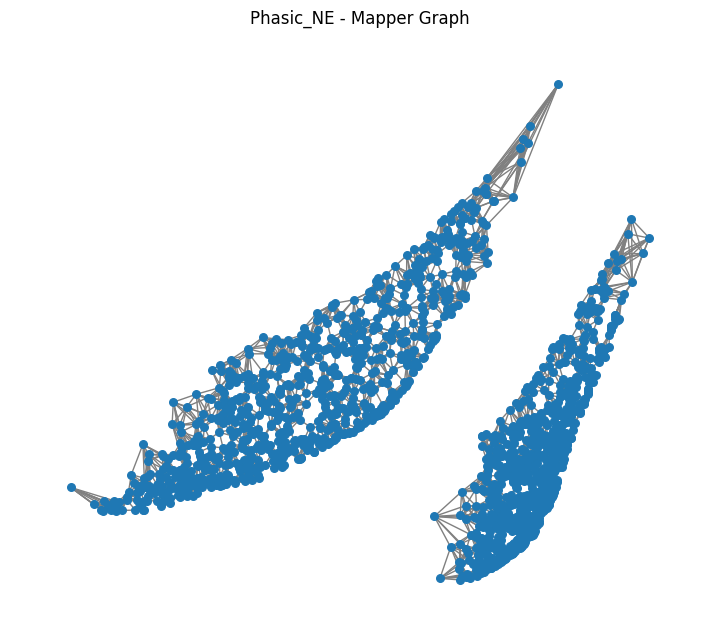

Analyzing Hidden_1 activations...


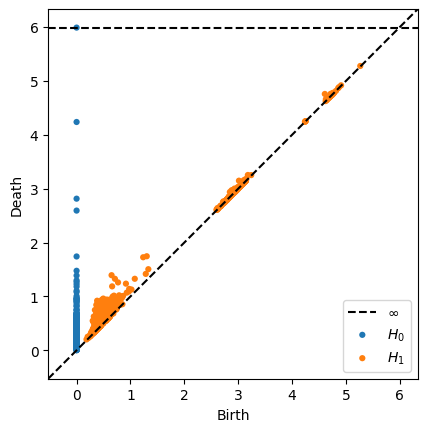

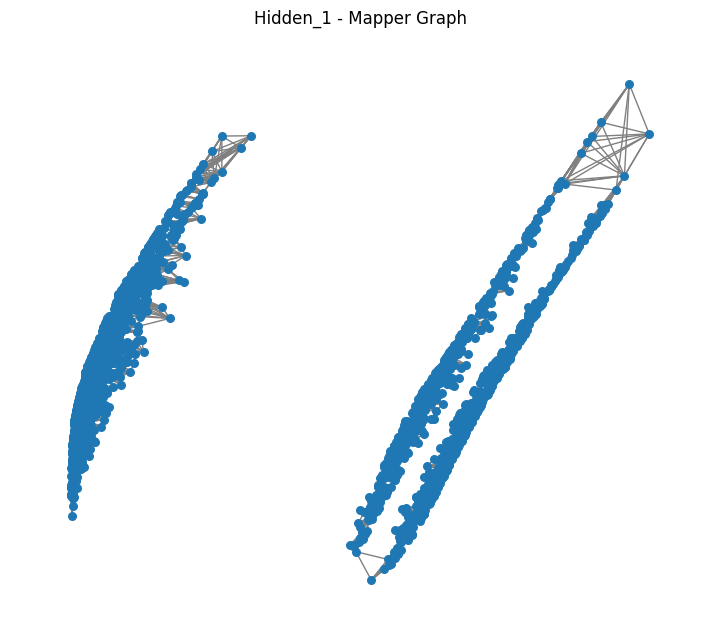

Analyzing Hidden_2 activations...


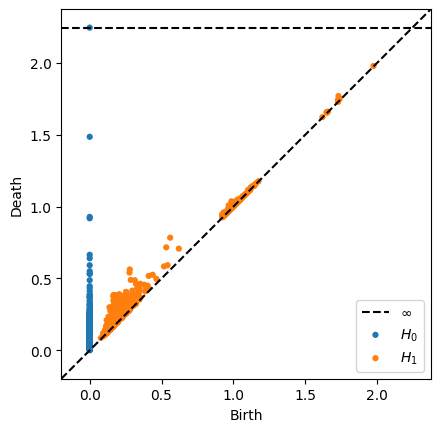

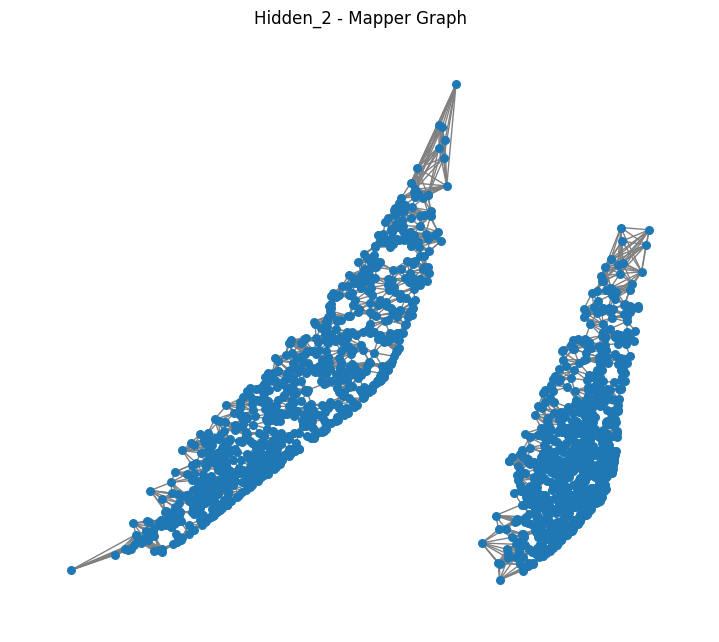

In [39]:
activations = extract_activations(ff_uncertain_gadget, X_tensor)

for key, act in activations.items():
    print(f"Analyzing {key} activations...")
    compute_persistent_homology(act, title=f"{key} - Persistent Homology")
    compute_mapper_graph(act, title=f"{key} - Mapper Graph")
